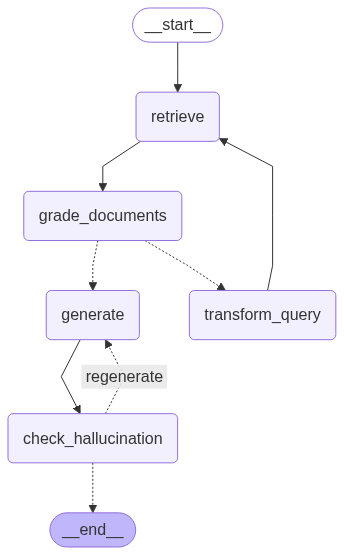

In [1]:
import os
import time
from collections import defaultdict
from operator import add
from typing import Annotated

import litellm
import pandas as pd
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

import agent_k.config.general as config_general
from agent_k.config.logger import logger
from agent_k.config.prompts_fast_n_slow import (
    QUESTION_TEMPLATE,
)
from agent_k.config.schemas import (
    TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION,
    TOTAL_MINERAL_RESERVE_TONNAGE_DESCRIPTION,
    TOTAL_MINERAL_RESOURCE_CONTAINED_METAL_DESCRIPTION,
    TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
from agent_k.notebooks.agentic_rag_v5 import create_markdown_retriever
from agent_k.tools.python_code_interpreter import PythonExecTool

# Configs

In [2]:
MODEL = "gpt-4.1-mini"
TEMPERATURE = 0.1

STEP_BACK_PROMPT = """Given a question that requires numerical reasoning, identify the math formula and numerical values required to solve the question. Generate a few examples without calculating the answer to help yourself understand the question.

# Question
{question}
"""

EXTRACT_PROMPT = """Given a question that requires numerical reasoning and context from documents, extract the numerical values that are required to solve the question based on your previous reasoning of the question.

All extracted values must be present in the original context. If no relevant values are found, return "No relevant values found".

# Question
{question}

# Context
{context}
"""

PROGRAM_REASONER_SYS_PROMPT = """You are a helper assistant that generate a python program to solve the question based on the given question and the context. The final answer should be assigned to the variable `ans`. Enclose the python code in ```python and ``` code block."""

PROGRAM_REASONER_USER_PROMPT = """Based on the previous given question, context, reasoning, and extracted values, generate a python program to answer the question."""

# Graph

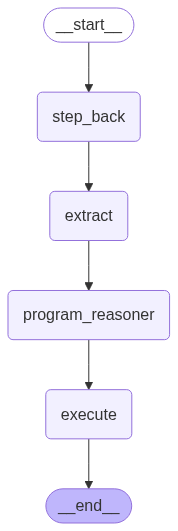

In [3]:
class GraphState(TypedDict):
    question: str
    context: str
    messages: Annotated[list[str], add]
    answer: float


def step_back(state: GraphState):
    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            {
                "role": "user",
                "content": STEP_BACK_PROMPT.format(question=state["question"]),
            }
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {
                "role": "user",
                "content": STEP_BACK_PROMPT.format(question=state["question"]),
            },
            {"role": "assistant", "content": content},
        ]
    }


def extract(state: GraphState):
    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            *state["messages"],
            {
                "role": "user",
                "content": EXTRACT_PROMPT.format(
                    question=state["question"], context=state["context"]
                ),
            },
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {
                "role": "user",
                "content": EXTRACT_PROMPT.format(
                    question=state["question"], context=state["context"]
                ),
            },
            {"role": "assistant", "content": content},
        ]
    }


def program_reasoner(state: GraphState):
    response = litellm.completion(
        model=MODEL,
        temperature=TEMPERATURE,
        messages=[
            {"role": "system", "content": PROGRAM_REASONER_SYS_PROMPT},
            *state["messages"],
            {"role": "user", "content": PROGRAM_REASONER_USER_PROMPT},
        ],
    )
    content = response["choices"][0]["message"]["content"]
    return {
        "messages": [
            {"role": "user", "content": PROGRAM_REASONER_USER_PROMPT},
            {"role": "assistant", "content": content},
        ]
    }


def execute(state: GraphState):
    msg_w_code = state["messages"][-1]["content"]
    output = PythonExecTool().run_code_block(msg_w_code)
    return {"answer": output}


graph_builder = StateGraph(GraphState)
graph_builder.add_node("step_back", step_back)
graph_builder.add_node("extract", extract)
graph_builder.add_node("program_reasoner", program_reasoner)
graph_builder.add_node("execute", execute)

graph_builder.add_edge(START, "step_back")
graph_builder.add_edge("step_back", "extract")
graph_builder.add_edge("extract", "program_reasoner")
graph_builder.add_edge("program_reasoner", "execute")
graph_builder.add_edge("execute", END)

display(
    Image(
        graph_builder.compile()
        .get_graph()
        .draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
if __name__ == "__main__":
    question = QUESTION_TEMPLATE.format(
        field="total_mineral_resource_tonnage",
        dtype="float",
        default=0,
        description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
    )

    retriever = create_markdown_retriever(
        "paper/data/processed/43-101-refined/022b81881794b6910528a035b50a214fc960c52f89d7f84a35ce1b75b96f3759f0.md",
        collection_name="rag-chroma",
    )

    documents = retriever.invoke(question)

    graph_inputs = {
        "question": question,
        "context": documents,
    }

    # Compile graph and invoke
    graph = graph_builder.compile()
    value = graph.invoke(graph_inputs, config={"recursion_limit": 12})

    # Final generation
    logger.info("---FINAL GENERATION---")
    logger.info(value["answer"])

# Run Experiments

In [4]:
complex_properties = [
    (
        "total_mineral_resource_tonnage",
        "float",
        0,
        TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
    ),
    (
        "total_mineral_reserve_tonnage",
        "float",
        0,
        TOTAL_MINERAL_RESERVE_TONNAGE_DESCRIPTION,
    ),
    (
        "total_mineral_resource_contained_metal",
        "float",
        0,
        TOTAL_MINERAL_RESOURCE_CONTAINED_METAL_DESCRIPTION,
    ),
    (
        "total_mineral_reserve_contained_metal",
        "float",
        0,
        TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION,
    ),
]


def run_experiment(gt_path: str, output_dir: str):
    df_gt = pd.read_csv(gt_path)

    rows = []
    tokens = defaultdict(int)
    start_time = time.time()
    for index, row in df_gt.iterrows():
        # if index > 0:
        #     break

        logger.info(f"Processing row {index + 1} of {len(df_gt)}")
        id = row["id"]
        cdr_record_id = row["cdr_record_id"]
        commodity_observed_name = row["commodity_observed_name"]
        row_template = {
            "id": id,
            "cdr_record_id": cdr_record_id,
            "commodity_observed_name": commodity_observed_name,
            "total_mineral_resource_tonnage": -1,
            "total_mineral_reserve_tonnage": -1,
            "total_mineral_resource_contained_metal": -1,
            "total_mineral_reserve_contained_metal": -1,
        }

        retriever = create_markdown_retriever(
            f"paper/data/processed/43-101-refined/{cdr_record_id}.md",
            collection_name="rag-chroma",
        )
        for (
            property_name,
            property_dtype,
            property_default,
            property_description,
        ) in complex_properties:
            question = QUESTION_TEMPLATE.format(
                field=property_name,
                dtype=property_dtype,
                default=property_default,
                description=property_description.replace(
                    "<main_commodity>", commodity_observed_name
                ),
            )
            documents = retriever.invoke(question)
            graph_inputs = {
                "question": question,
                "context": documents,
            }
            # Compile graph and invoke
            graph = graph_builder.compile()
            value = graph.invoke(graph_inputs, config={"recursion_limit": 12})
            row_template[property_name] = value["answer"]

        rows.append(row_template)

    df_pred = pd.DataFrame(rows)
    logger.info(
        f"Successfully extracted {len(df_pred)} reports. Write to experiment results directory."
    )
    # Generate timestamp once for both files
    os.makedirs(output_dir, exist_ok=True)

    # Save results to CSV
    timestamp = config_general.get_curr_ts()
    df_pred.to_csv(f"{output_dir}/{timestamp}_ere_extraction.csv", index=False)


if __name__ == "__main__":
    output_dir = "paper/data/experiments/250629_extract_reason_exec"
    gt_path = "paper/data/processed/ground_truth/inferlink_ground_truth.csv"
    run_experiment(
        gt_path=gt_path,
        output_dir=output_dir,
    )

2025-06-29 18:04:19.005 | INFO     | __main__:run_experiment:19 - Processing row 1 of 50
2025-06-29 18:04:19.065 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:116 - Number of tokens: 49301
2025-06-29 18:04:19.066 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:117 - Number of splits: 52
2025-06-29 18:04:19.066 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:118 - Average tokens per split: 948
2025-06-29 18:04:19.224 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:131 - Hashed collection name: rag-chroma_shard_3
2025-06-29 18:05:44.873 | INFO     | __main__:run_experiment:19 - Processing row 2 of 50
2025-06-29 18:05:44.947 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:116 - Number of tokens: 55017
2025-06-29 18:05:44.948 | INFO     | agent_k.notebooks.agentic_rag_v5:create_markdown_retriever:117 - Number of splits: 83
2025-06-29 18:05:44.949 | INFO     | agent_k.no

# Schema Map Reduce

In [ ]:
from typing import Any, Literal, TypedDict

from langgraph.types import Send


class State(TypedDict):
    md_path: str
    json_schema: dict
    retriever: Any


class ComplexEntityState(TypedDict):
    entity_name: str
    description: str
    default_value: Any
    dtype: Literal["string", "number", "boolean", "array", "object"]
    retriever: Any


def map_extraction_route(state: State):
    next_nodes = []

    for entity_name, entity_schema in state["json_schema"]["properties"].items():
        next_nodes.append(
            Send(
                "map_extract_reason_exec",
                {
                    "entity_name": entity_name,
                    "description": entity_schema.get("description"),
                    "default_value": entity_schema.get("default"),
                    "dtype": entity_schema.get("type"),
                    "retriever": state["retriever"],
                },
            )
        )

    return next_nodes


map_reduce_graph_builder = StateGraph(State)